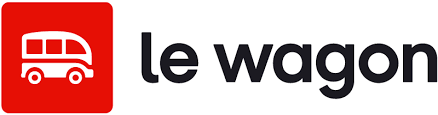

# Non-linear model

In the following challenge, we'll try to predict medical insurance charges based on certain factors!

While we're sure you find that premise interesting, the important part of this challenge is not the data, it's the modelling! We'll try to implement some **new** models that we haven't seen before.

Remember one thing: the goal of this challenge is not to give you an understanding of the mathematical intricacies of these models - that's the job of a data scientist. However, we want to show you just how easy these models are to code and how friendly the SKLearn Library is!

## Import the data

Go to [this](https://www.kaggle.com/datasets/mirichoi0218/insurance) link and download the medical insurance charges dataset. Load it into a dataframe!

In [ ]:
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [22]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Preprocessing

Before doing any preprocessing let's build our baseline.

### Split into X and y

Choose the appropriate columns to assign to the X and y variables!

In [23]:
X = df.drop(columns='charges')
y = df['charges']

### Train-test split

Split your data now, into train and test variables (80/20)!

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### Baseline

Here take only the numerical features and use a Linear Regression.

Think about the metric we need to use to evaluate our models.

<details>
<summary>Hint 1:</summary>

We are in a regression problem.
</details>
<details>
<summary>Hint 2:</summary>

You can look on scikit learn [documentation](https://scikit-learn.org/stable/modules/model_evaluation.html).</details>

In [25]:
X_train_num = X_train.select_dtypes(include=['float64', 'int64'])
X_test_num = X_test.select_dtypes(include=['float64', 'int64'])

Now our baseline is build let's do our preprocessing and see if we can decrease the model error.

### Scaling

Like in the previous exercise, we'll have to scale the numerical **and** non-numerical columns!

### Numerical values

Scale the numerical values - remember from the last challenge what we did to select only the relevant columns.

<details>
    <summary><i>Hint:</i></summary>
You have to fit it on the train and not on the test.
</details>

In [26]:
scaler = StandardScaler().set_output(transform='pandas')

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

### Non-numerical values

Now it's time to scale the non-numerical values as well. Use `pd.get_dummies`!
Save each into 'X_train_cat' and 'X_test_cat'.

In [27]:
X_train_cat = X_train.select_dtypes(exclude=['float64', 'int64'])
X_test_cat = X_test.select_dtypes(exclude=['float64', 'int64'])

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')

X_train_cat_enc = enc.fit_transform(X_train_cat)
X_test_cat_enc = enc.transform(X_test_cat)

What is the number of columns of each 'X_train_cat' and 'X_test_cat'?
<details>
 <summary><i>Answer:</i></summary>
 You are suppose to have 8 columns.
</details>

In [28]:
len(X_train_cat_enc.columns)

8

### Rebuild X!

Concat your numerical and non-numerical Xs into one! Store it in 'X_train_preproc' and 'X_test_preproc'

Check if you have nan in your dataframes.
<details>
    <summary>Hint:</summary>
If you have nan in it is because of the way `pd.get_dummies` works. It is not reset the index of your dataframe and so you have different index for the concatenation.
<details>
<summary>Answer:</summary>
You have to use `pd.reset_index` on your categorical dataframes.
</details>
</details>

In [29]:
X_train_preprocessed = pd.concat((X_train_cat_enc, X_train_num_scaled), axis=1)
X_test_preprocessed = pd.concat((X_test_cat_enc, X_test_num_scaled), axis=1)

## Modelling!

It's time to do some modelling, only this time, we're going beyond Linear Regressions!

### Linear Regression

Perform a Linear Regression on the data!

In [33]:
lin_reg = LinearRegression()

lin_reg.fit(X_train_preprocessed, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Now, calculate the MAE of your Linear Regression!

In [35]:
print(f'R2: {lin_reg.score(X_test_preprocessed, y_test)}')

y_pred = lin_reg.predict(X_test_preprocessed)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')

R2: 0.7999876970680433
MSE: 31827950.2295
MAE: 3933.2726


We divide our error by more than 2. As you can see the preprocessing is really important if you want modelling.

Be sure everything before is **understanding** before start the optional.

# Optional

Choosing the appropriate model can also reduce errors. There are various types of models available for regression let's try a few!

### Trees - Random Forest Regression

Now we're getting a bit more complex! Look up the sklearn documentation for the `RandomForestRegressor` and see how you could implement it for our dataset!

Don't spend too much time trying to understand how this model works under the hood, that's not the purpose here. However, if you're curious, watch [this short video](https://www.youtube.com/watch?v=gkXX4h3qYm4) from IBM that explains the basics.

In [38]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor()
rfr.fit(X_train_preprocessed, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Now it's time to calculate the MAE of the Random Forest model.

In [39]:
print(f'R2: {rfr.score(X_test_preprocessed, y_test)}')

y_pred = rfr.predict(X_test_preprocessed)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')

R2: 0.8825894269605501
MSE: 18683540.0640
MAE: 2576.3358


### Support Vector Machine

Same drill as last time, only now we're trying the `Support Vector Regressor`. Again, look up the documentation of this model and implement it below.

[Here's](https://www.youtube.com/watch?v=_YPScrckx28) a very short video that explains the idea behind SVM's. Don't dwell too much on trying to understand how it works, only the basics!

In [40]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train_preprocessed, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


Let's calculate the MAE now!

In [41]:
print(f'R2: {svr.score(X_test_preprocessed, y_test)}')

y_pred = svr.predict(X_test_preprocessed)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')

R2: -0.10260537581137474
MSE: 175457551.9090
MAE: 8580.8017


### Your own model

Look through the SKLearn documentation to find another regression model and try your best to implement it. How does it perform?

In [42]:
from sklearn.linear_model import Ridge

rdg = Ridge()
rdg.fit(X_train_preprocessed, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


Calculate the error of your model!

In [43]:
print(f'R2: {rdg.score(X_test_preprocessed, y_test)}')

y_pred = rdg.predict(X_test_preprocessed)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')

R2: 0.7997999213405016
MSE: 31857830.9740
MAE: 3939.1387


## Conclusions

The results are in! The model that perfomed best was the random forest, followed by the linear regression and trailing in last place, the SVR! This goes to show that the most complex models are not always the best!

How did your model do?

**A little caveat:** this was a very simplistic implementation of what are complex models. In a more realistic scenario, a data scientist would have spent a considerable portion of their time on finetuning these models to improve their performance. In this challenge, the purpose was not to do that, but rather to show how easy the Sci-Kit Learn Library is to use!